# $\mathcal{U}^{10} + \mathcal{U}^{80} + \mathcal{U}^{200} \in \mathbb{R}^{1024}$

### Setup environment

In [1]:
import sys, os, importlib
print(sys.path)

PATH_ROOT  = "/root/workspace/Python/flipd/"
PATH_MODEL = "/root/workspace/Python/flipd/notebooks/outputs/notebooks/"
PATH_FIG   = "/root/workspace/Python/flipd/notebooks/figs/50k/"

os.chdir(PATH_ROOT)
!pwd

['/root/workspace/Python/flipd/notebooks', '/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor']
/root/workspace/Python/flipd


### Load data

In [2]:
from models.training import LightweightTrainer
from models.diffusions.training import LightningDiffusion
from functools import partial
import torch.optim as optim
import torch
import numpy as np
from tqdm import tqdm

from models.diffusions.sdes import VpSde, VeSde
from models.diffusions.networks import MLPUnet

device = torch.device('cuda:3')

2026-04-02 20:27:56.266166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-02 20:27:56.290050: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-02 20:27:56.297360: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-02 20:27:56.315521: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-02 20:27:57.596039: W tensorflow/comp

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [3]:
import matplotlib.pyplot as plt
import visualization.scatterplots as scatterplots
importlib.reload(scatterplots)
from visualization.scatterplots import visualize_3d_clusters
from visualization.pretty import ColorTheme

from data.distributions import AffineManifoldMixture
from data.datasets.generated import LIDSyntheticDataset

ambient_dim = 1024

distribution = AffineManifoldMixture(
    manifold_dims=[10, 80, 200],
    ambient_dim=ambient_dim,
    sample_distr="uniform",
    affine_projection_type="random-rotation",
    seed=111,
    distance_between_modes=10,
)

dset = LIDSyntheticDataset(size=50_000, distribution=distribution, standardize=True, seed=42)

/opt/conda/lib/python3.10/site-packages/torch/random.py:166: UserWarning: CUDA reports that you have 8 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  warnings.warn(message)


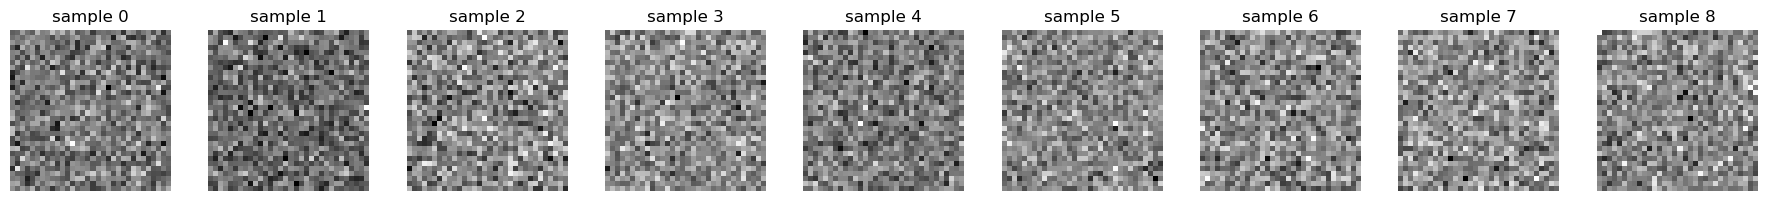

In [4]:
from torch.utils.data import DataLoader
loader = DataLoader(dset, batch_size=16, shuffle=True)

batch = next(iter(loader))

if isinstance(batch, dict):
    x = batch["x"]
elif isinstance(batch, (list, tuple)):
    # e.g. (x, lid)
    x = batch[0]
else:
    # e.g. just a tensor
    x = batch

x = x.view(x.size(0), 1, 32, 32).detach().cpu()

x_min = x.view(x.size(0), -1).min(dim=1)[0].view(-1, 1, 1, 1)
x_max = x.view(x.size(0), -1).max(dim=1)[0].view(-1, 1, 1, 1)
x_norm = (x - x_min) / (x_max - x_min + 1e-8)

n_show = min(9, x_norm.size(0))
fig, axes = plt.subplots(1, n_show, figsize=(2*n_show, 2))

for i in range(n_show):
    axes[i].imshow(x_norm[i, 0], cmap="gray", interpolation="nearest")
    axes[i].axis("off")
    axes[i].set_title(f"sample {i}")

plt.tight_layout()
plt.show()

In [ ]:
import gc, torch, contextlib
def free_cuda(*objs):
    # drop strong refs
    for o in objs:
        try:
            del o
        except:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()  # helpful in notebooks
        print("GPU freed.",
              "alloc=", round(torch.cuda.memory_allocated()/1e6,1), "MB,",
              "reserved=", round(torch.cuda.memory_reserved()/1e6,1), "MB")
free_cuda(trainer, vp_sde, score_net, data,adapter)  # anything large

### Train VP SDE

In [ ]:
IS_CONV2D = True
IS_CONV2D_LIGHT = False

if IS_CONV2D:
    from models.diffusions.networks import UNet2D
    ambient_dim_img = (1, 32, 32)
    if IS_CONV2D_LIGHT:
        score_net = UNet2D(
            sample_size=32, in_channels=1,out_channels=1, layers_per_block=2,
            block_out_channels=(128, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "UpBlock2D",),
            t_factor=1000,   # matches your adapter’s timestep scaling
        ).to(device)
        ckpt_path= os.path.join(PATH_MODEL, "50k_1024D_10d_80d_200d_uniform_idr_unet2d_vp")
    else:
        score_net = UNet2D(
            sample_size=32, in_channels=1,out_channels=1, layers_per_block=2,
            block_out_channels=(128, 256, 256),
            down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
            t_factor=1000,
        ).to(device)
        ckpt_path= os.path.join(PATH_MODEL, "50k_1024D_10d_80d_200d_uniform_idr_unet2d_rich_vp")

    class UNet2DFlatAdapter(torch.nn.Module):
        """
        Wrap a trained UNet2D that expects (B,1,28,28) so it can be used
        with flat inputs (B,784) and returns flat outputs (B,784).
        """
        def __init__(self, unet2d: torch.nn.Module, H: int = 32, W: int = 32, C: int = 1):
            super().__init__()
            self.unet2d = unet2d   # your trained UNet2D (diffusers adapter)
            self.H, self.W, self.C = H, W, C
            self.D = C * H * W

        def forward(self, x, t):
            # x can be (B,D) or already (B,C,H,W)
            if x.ndim == 2:
                B = x.shape[0]
                x = x.view(B, self.C, self.H, self.W)
            elif x.ndim == 4:
                B = x.shape[0]
            else:
                raise ValueError(f"Expected x.ndim in {{2,4}}, got {x.ndim}")
            out = self.unet2d(x, t)          # (B,1,28,28)
            return out.view(B, self.D)       # flatten back to (B,D)

    adapter = UNet2DFlatAdapter(score_net, H=32, W=32, C=1).to(device)
    vp_sde = VpSde(score_net=adapter).to(device)
else:
    score_net = MLPUnet(ambient_dim, hidden_sizes=(1024, 1024, 512, 512, 256, 128), time_embedding_dim=128).to(device)
    ckpt_path= os.path.join(PATH_MODEL, "50k_1024D_10d_80d_200d_uniform_vp")
    vp_sde = VpSde(score_net=score_net).to(device)

print(ckpt_path)

trainer = LightweightTrainer(max_epochs=300, device=device,)
trainer.fit(
    model=LightningDiffusion(sde=vp_sde, optim_partial=partial(optim.Adam, lr=1e-4)),
    train_dataloader=torch.utils.data.DataLoader(dset.x, batch_size=500, shuffle=True),
    ckpt_path=ckpt_path,
)

/root/workspace/Python/flipd/notebooks/outputs/notebooks/50k_1024D_10d_80d_200d_uniform_idr_unet2d_rich_vp


Training epochs [Batch 33/100]:  53%|█████▎    | 160/300 [00:43<?, ?it/s]

### VE SDE

### Generate and visualize samples to check the model trained properly

In [ ]:
from visualization import visualize_3d_clusters
from visualization import visualize_umap_clusters
from visualization.pretty import ColorTheme

n_samples = 500

noise = torch.randn(n_samples, ambient_dim).to(device)
vp_sde: VpSde
gen_samples = vp_sde.solve_reverse_sde(noise, steps=1000)

visualize_umap_clusters(
    data = [gen_samples.cpu().detach().numpy(), dset.x[:n_samples].cpu().numpy()],
    labels=["generated", "real"],
    title="quality of model",
    alpha=0.3,
    colors=[ColorTheme.GOLD.value, ColorTheme.BLUE_SECOND.value],
    return_img=False,
)

## LID Estimation

In [6]:
# reload for debug 
import importlib, sys
importlib.invalidate_caches()

import lid.base as lid_base
importlib.reload(lid_base)

from lid.diffusions import local_hessian_spectrum as lhs
importlib.reload(lhs)

import lid.diffusions as lid_diffusions
importlib.reload(lid_diffusions)

from lid.diffusions.local_hessian_spectrum import (
    LocalHessianSpectralEstimator, VPSchedule, VESchedule
)

In [7]:
from lid.evaluation.lid_evaluation import mae
import numpy as np

n_samples = 500

# Initialize estimator
lid_estimator_soft_dof = LocalHessianSpectralEstimator(
    vp_sde, 
    VPSchedule(beta_min=0.1, beta_max=20.0), 
    method="Soft_DoF", 
    soft_c=0.1, 
    soft_p=4,
    ambient_dim=ambient_dim, 
    device=device, 
    batch_size=n_samples,
    lanczos_m=2 # Default, will be overridden in the loop
)

data = dset.x[:n_samples].to(device)
gt_lid = dset.lid[:n_samples].to(device).cpu().numpy()

deltas = np.linspace(0.001, 0.2, 8)
#m_steps_list = [2, 5, 10, 20]
m_steps_list = [5, 10, 20]

for m in m_steps_list:
    print(f"--- Evaluating with Lanczos steps m={m} ---")
    for delta in deltas:
        # Override lanczos_m dynamically
        lid_soft_dof = lid_estimator_soft_dof.estimate_lid(
            data, 
            delta=delta, 
            lanczos_m=m
        ).cpu().numpy()
        
        error = mae(lid_soft_dof, gt_lid)
        print(f'SoftDoF (m={m}): delta={delta:.5f}, MAE={error:.6f}')
    print("-" * 40)

--- Evaluating with Lanczos steps m=5 ---
SoftDoF (m=5): delta=0.00100, MAE=533.575942
SoftDoF (m=5): delta=0.02943, MAE=45.606747
SoftDoF (m=5): delta=0.05786, MAE=10.336325
SoftDoF (m=5): delta=0.08629, MAE=15.926730
SoftDoF (m=5): delta=0.11471, MAE=11.657598
SoftDoF (m=5): delta=0.14314, MAE=12.489790
SoftDoF (m=5): delta=0.17157, MAE=17.398883
SoftDoF (m=5): delta=0.20000, MAE=24.081693
----------------------------------------
--- Evaluating with Lanczos steps m=10 ---
SoftDoF (m=10): delta=0.00100, MAE=533.649593
SoftDoF (m=10): delta=0.02943, MAE=44.584103
SoftDoF (m=10): delta=0.05786, MAE=4.213360
SoftDoF (m=10): delta=0.08629, MAE=10.023038
SoftDoF (m=10): delta=0.11471, MAE=12.447249
SoftDoF (m=10): delta=0.14314, MAE=14.409834
SoftDoF (m=10): delta=0.17157, MAE=18.083762
SoftDoF (m=10): delta=0.20000, MAE=22.269205
----------------------------------------
--- Evaluating with Lanczos steps m=20 ---
SoftDoF (m=20): delta=0.00100, MAE=533.782127
SoftDoF (m=20): delta=0.02943, 

In [ ]:
## Elapsed Time 

In [19]:
import notebooks.utils.utils as utils 
importlib.reload(utils)
from notebooks.utils.utils import measure_inference_time

m_steps_list = [2, 5, 10, 20, 40]

print(f"{'Lanczos Steps (m)':<20} | {'Inference Time (ms)':<20}")
print("-" * 45)
delta = 0.029428571428571432

time_results = {}

for m in m_steps_list:
    t_ms = measure_inference_time(
        estimator=lid_estimator_soft_dof,
        x=data,  t=delta, lanczos_m=m 
    )
    
    time_results[m] = t_ms
    print(f"{m:<20} | {t_ms:.2f}")

print("-" * 45)

Lanczos Steps (m)    | Inference Time (ms) 
---------------------------------------------
2                    | 3233.65
5                    | 8075.36
10                   | 16140.69
20                   | 32336.87
40                   | 68798.52
---------------------------------------------


... saved /root/workspace/Python/flipd/notebooks/figs/1024D_10d_80d_200d_uniform.png


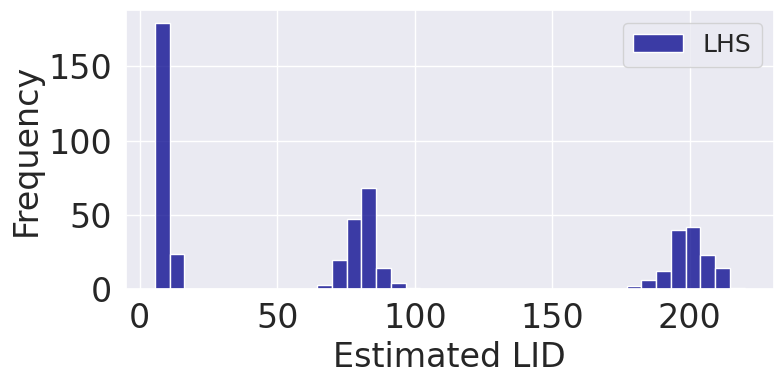

In [21]:
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_histograms 

delta = 0.05786
m = 10
lid_soft_dof = lid_estimator_soft_dof.estimate_lid(data, delta=delta, lanczos_m=10).cpu().numpy()

filename = os.path.join(PATH_FIG, "1024D_10d_80d_200d_uniform")
plot_histograms([lid_soft_dof], labels=['LHS'], filename=filename)


Computing eigenvalues for 20 samples (Dimension=1024)...


Computing Hessian (1024 dims): 100%|██████████| 1024/1024 [00:08<00:00, 121.49it/s]


... saved /root/workspace/Python/flipd/notebooks/figs/1024D_10d_80d_200d_uniform_hessian_spectrum_0.2.png


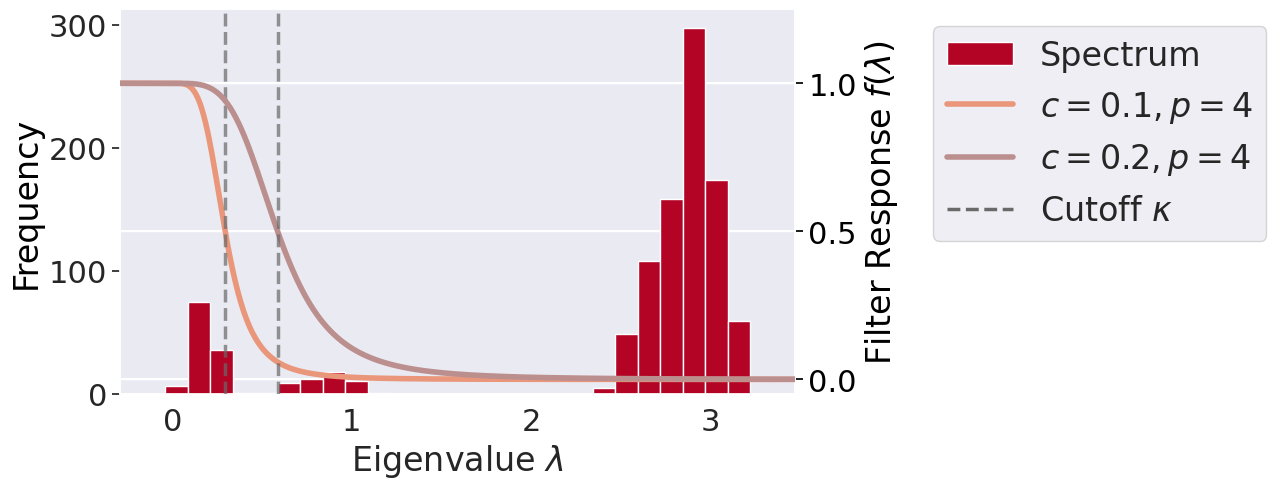

In [30]:
import notebooks.utils.utils as utils 
importlib.reload(utils)
from notebooks.utils.utils import plot_eigenvalue_spectrum_with_filter
delta_t = 0.2
schedule = VPSchedule(beta_min=0.1, beta_max=20.0)
sigma2 = schedule.sigma2(delta_t)

x = data[:20].to(device)
sigma_val = np.sqrt(sigma2)
z = torch.randn_like(x)
x_noisy = x + sigma_val * z


pairs = [
    [0.1, 4], 
    #[0.1, 12], 
    [0.2, 4],
    #[0.2, 12], 
    #[0.4, 4],
    #[0.4, 12],
]


_ = plot_eigenvalue_spectrum_with_filter(
    sde=vp_sde,  # Adapter SDE
    x_batch=x_noisy, 
    t_val=delta_t, 
    sigma2_val=schedule.sigma2(delta_t),
    p_c_pairs=pairs,
    filename=os.path.join(PATH_FIG, "1024D_10d_80d_200d_uniform_hessian_spectrum_%s.png"%(delta_t))
)


Sweep t (Transition mass; B=20, D=1024): 100%|██████████| 20/20 [02:48<00:00,  8.44s/it]


... saved /root/workspace/Python/flipd/notebooks/figs/FilterDiag/1024D_10d_80d_200d_uniform.png


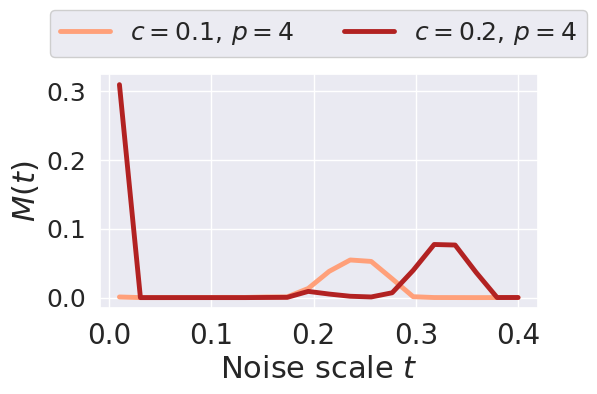

In [31]:
import notebooks.utils.utils as utils 
importlib.reload(utils)
from notebooks.utils.utils import plot_transition_mass_over_t

delta_list = np.linspace(0.01, 0.4, 20)
schedule = VPSchedule(beta_min=0.1, beta_max=20.0)

pairs = [
    [0.1, 4],
    [0.2, 4],
    #[0.4, 4],
]

res = plot_transition_mass_over_t(
    sde=vp_sde,
    schedule=schedule,
    x_batch=data[:20].to(device),
    t_list=delta_list,
    p_c_pairs=pairs,
    eps_rel=0.2,
    filename=os.path.join(PATH_FIG, "FilterDiag", "1024D_10d_80d_200d_uniform"),
)

## Competitor - Normal Bundle

While the original paper suggests t ~= 0 and the default value of this FLIPD codebase is 1e-4, larger t seems better.

In [ ]:
from lid.diffusions import NormalBundleEstimator
lid_estimator_nb = NormalBundleEstimator(model=vp_sde, ambient_dim=ambient_dim, device=device,)

deltas = np.linspace(0.001, 0.2, 8)
for delta in deltas:
    lid = lid_estimator_nb.estimate_lid(data, noise_time=delta).detach().cpu().numpy()
    print('NB:', delta, mae(lid, gt_lid))

## Competitor - LIDL

In [ ]:
from lid.diffusions.fokker_planck import FPRegressEstimator
lid_estimator_lidl = FPRegressEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)
lid = lid_estimator_lidl.estimate_lid(data).detach().cpu().numpy()
print('LIDL:', mae(lid, gt_lid))

## Competitor - FLIPD

In [ ]:
# from lid.diffusions.fokker_planck import FlipdEstimator
lid_estimator_flipd = FlipdEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)

deltas = np.linspace(0.001, 0.2, 8)
for delta in deltas:
    lid = lid_estimator_flipd.estimate_lid(data, t=delta).detach().cpu().numpy()
    print('FLIPD:', delta, mae(lid, gt_lid))

## Competitor - ESS

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator

data_train = dset.x[-n_samples:]

est = SkdimLIDEstimator(data=data_train, ambient_dim=ambient_dim, estimator_type="ESS")
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('ESS:', mae(lid, gt_lid))

In [ ]:
data_train = dset.x[-10000:]

est = SkdimLIDEstimator(data=data_train, ambient_dim=ambient_dim, estimator_type="ESS")
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('ESS 10k:', mae(lid, gt_lid))

est.fit(n_neighbors=200)
lid = est.estimate_lid(data).cpu().numpy()
print('ESS 10k:', mae(lid, gt_lid))

## Competitor - LPCA

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator

data_train = dset.x[-n_samples:]

est = SkdimLIDEstimator(data=data_train, ambient_dim=ambient_dim, estimator_type="lPCA")
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('LPCA:', mae(lid, gt_lid))

In [ ]:
data_train = dset.x[-10000:]

est = SkdimLIDEstimator(data=data_train, ambient_dim=ambient_dim, estimator_type="lPCA")
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('ESS 10k:', mae(lid, gt_lid))

est.fit(n_neighbors=200)
lid = est.estimate_lid(data).cpu().numpy()
print('ESS 10k:', mae(lid, gt_lid))